/Users/yushe/Desktop/UNI/FALL26/CSCD94/FlexibleEmissionHMM/.venv/lib/python3.10/site-packages/hmmlearn/hmm.py:352: RuntimeWarning: invalid value encountered in divide
  self.means_ = ((means_weight * means_prior + stats['obs'])


Training: 1988-1997; evaluation: 1998-2001; no evaluation tuning

Training moments and heuristic regime names:
    mean_r_%day  sd_r_%day  mean_sigma_%day    regime
0       -0.009      1.085            1.036  sideways
1        0.076      0.697            0.671      bull
2       -0.003      2.050            1.743      bear

Transitions:
 [[0.964 0.026 0.011]
 [0.007 0.992 0.001]
 [0.062 0.    0.938]]

RF training accuracy: 0.561

Causal regime day counts:
 regime
bear         272
sideways     581
bull         151
test_all    1004

Sharpe by causal regime:
                bear  sideways  bull  test_all
buy_and_hold   1.11     -0.31 -0.04      0.20
ma_50_200      1.10      0.08 -0.04      0.36
vol_target_60  0.84     -0.43 -0.18     -0.04
tsmom_126      0.60      0.29 -0.31      0.33
mean_rev_z20   0.94     -0.29  0.94      0.26
logistic_up    0.94     -0.26 -0.53      0.27
ridge_return   1.10     -0.30 -0.87      0.32
random_forest  0.20     -0.67 -0.66     -0.28

Signals use t-1 closes;

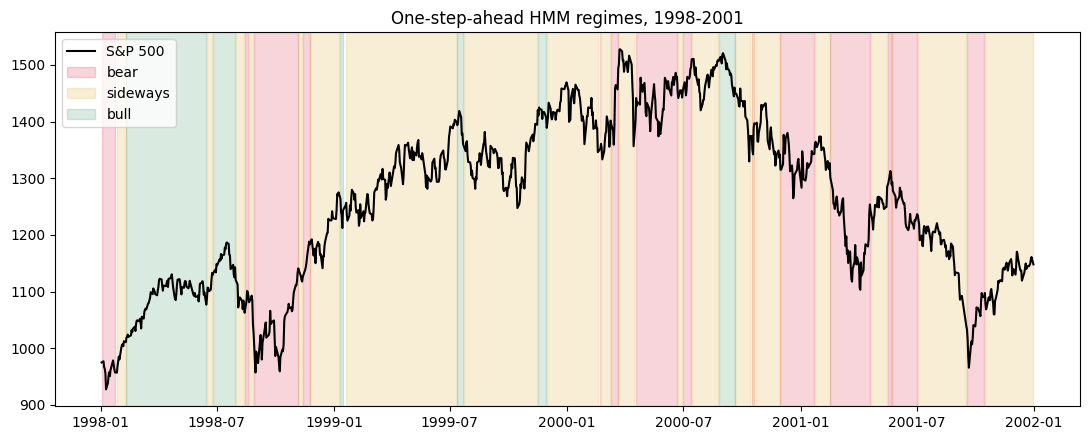

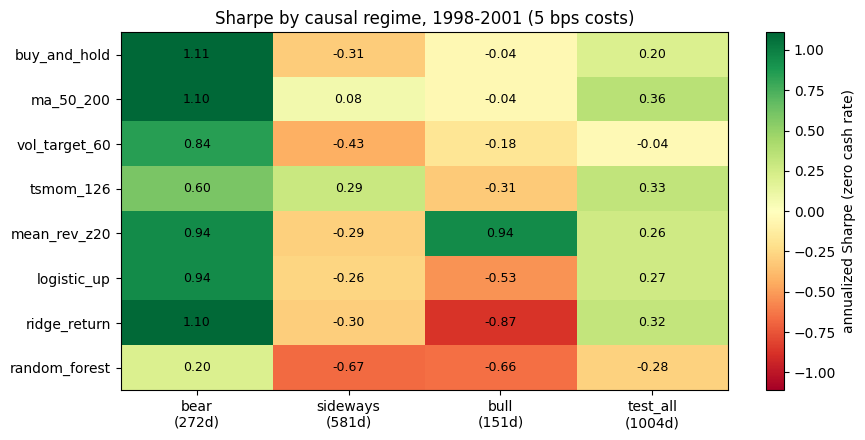

In [ ]:
"""Causal regime-by-algorithm Sharpe comparisons on existing S&P 500 prices."""

import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from hmmlearn.hmm import GaussianHMM
from scipy.special import expit
from sklearn.ensemble import RandomForestClassifier

PROJECT_ROOT = Path(__file__).resolve().parents[2]
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from model_evaluation.market_strategy import (  # noqa: E402
    apply_weights,
    buy_and_hold,
    hmmlearn_causal_probabilities,
    moving_average_timing,
    volatility_target,
)

DATA_PATH = PROJECT_ROOT / "data/processed/sp500_index_price.csv"
TRAIN_START, TRAIN_END = "1988-01-01", "1997-12-31"
EVAL_START, EVAL_END = "1998-01-01", "2001-12-31"
MAX_ITER, TOL = 120, 1e-3
MIN_COVAR = 1e-5
"""hmmlearn initialization regularizer, not a live EM eigenvalue floor."""

N_STATES, N_RESTARTS = 3, 10
"""Select the best of ten seeds by training likelihood only."""

VOLATILITY_DAYS, MOMENTUM_DAYS = 60, 20
COST_BPS = 5.0
"""Basis points per unit turnover, including initial entry from cash."""

REGIMES = ["bear", "sideways", "bull"]

# All hyperparameters are fixed; evaluation Sharpe never selects a model.
# Day t is the close-to-close interval ending at t. Signals use closes through
# t-1 only. Filling at that same close is an idealized execution assumption,
# not a claim that exact-close signals can be executed at the published close.
# Cash earns zero; apply_weights uses approximate log PnL and omits financing.

## Feature construction and training


def build_features(prices):
    """Build contemporaneous HMM emissions and lagged supervised inputs.

    Args:
        prices: Positive, finite closes with unique, increasing dates.

    Returns:
        Log returns, HMM emissions, and ML inputs indexed by target date.
        ML row t contains only observations through t-1. Rolling history is
        built before splitting so the first evaluation day is not cold-started.
    """
    if not prices.index.is_monotonic_increasing or not prices.index.is_unique:
        raise ValueError("Prices must have unique, increasing dates")
    if not np.isfinite(prices).all() or (prices <= 0).any():
        raise ValueError("Prices must be finite and positive")
    returns = np.log(prices).diff().dropna().rename("r_t")
    emissions = pd.concat(
        [
            returns,
            returns.rolling(VOLATILITY_DAYS).std(ddof=1).rename("sigma_t"),
            returns.rolling(MOMENTUM_DAYS).mean().rename("m_t"),
        ],
        axis=1,
    )
    # Shift the input rows, not predictions or labels, for both train and test.
    ml_features = emissions.shift(1).dropna()
    return returns, emissions.dropna(), ml_features


def fit_hmmlearn(features, n_states=N_STATES):
    """Fit restarts on training emissions and retain the best likelihood.

    Args:
        features: Training-only feature matrix in return, volatility, mean order.
        n_states: Number of hidden states.

    Returns:
        The highest-likelihood finite fitted model.
    """
    best, best_score = None, -np.inf
    for seed in range(N_RESTARTS):
        model = GaussianHMM(
            n_components=n_states, covariance_type="full", min_covar=MIN_COVAR,
            n_iter=MAX_ITER, tol=TOL, random_state=seed,
        )
        try:
            model.fit(features)
            score = model.score(features)
        except (ValueError, np.linalg.LinAlgError):
            continue
        if np.isfinite(score) and score > best_score:
            best, best_score = model, score
    if best is None:
        raise RuntimeError(f"All {N_RESTARTS} restarts failed")
    return best


def name_regimes(model):
    """Assign distinct descriptive names using training moments only.

    The highest-volatility state is called bear; the highest-return remaining
    state is bull; the leftover state is sideways. These are heuristic names,
    not evidence of negative bear returns or low sideways volatility.
    """
    if model.n_components != 3:
        raise ValueError("Regime naming requires exactly three states")
    fitted = pd.DataFrame(
        {
            "mean_r_%day": 100 * model.means_[:, 0],
            "sd_r_%day": 100 * np.sqrt(model.covars_[:, 0, 0]),
            "mean_sigma_%day": 100 * model.means_[:, 1],
        }
    )
    bear = int(fitted["sd_r_%day"].idxmax())
    remaining = fitted.drop(index=bear)
    bull = int(remaining["mean_r_%day"].idxmax())
    sideways = next(state for state in fitted.index if state not in (bear, bull))
    names = {bear: "bear", sideways: "sideways", bull: "bull"}
    fitted["regime"] = pd.Series(names)
    return names, fitted


def fit_ml(ml_features, returns):
    """Fit scaling and supervised models on 1988-1997 target dates only.

    Args:
        ml_features: Already lagged input rows indexed by target date.
        returns: Realized log returns indexed by the same target date.

    Returns:
        Frozen scaling, logistic coefficients, ridge coefficients, and forest.
        The last training target is in 1997; no 1998 label enters fitting.
    """
    features = ml_features.loc[TRAIN_START:TRAIN_END]
    targets = returns.loc[features.index]
    if features.empty or (targets > 0).nunique() != 2:
        raise ValueError("Training requires observations from both classes")
    mu, sd = features.mean(), features.std(ddof=0) + 1e-12
    scaled = ((features - mu) / sd).to_numpy()
    design = np.column_stack([np.ones(len(scaled)), scaled])
    y_up = (targets.to_numpy() > 0).astype(int)
    coefficients = np.zeros(design.shape[1])
    for _ in range(3000):
        probability = expit(design @ coefficients)
        gradient = design.T @ (probability - y_up) / len(y_up)
        gradient += coefficients / len(y_up)
        coefficients -= 0.05 * gradient
    ridge = np.linalg.solve(
        design.T @ design + 10.0 * np.eye(design.shape[1]),
        design.T @ targets.to_numpy(),
    )
    forest = RandomForestClassifier(
        n_estimators=300, max_depth=3, min_samples_leaf=50,
        random_state=0, n_jobs=-1,
    ).fit(scaled, y_up)
    return {
        "mu": mu, "sd": sd, "logistic": coefficients, "ridge": ridge,
        "return_sd": targets.std(ddof=1), "forest": forest,
        "train_accuracy": forest.score(scaled, y_up),
    }


## Causal inference and strategy positions


def causal_regimes(model, emissions, evaluation_index, names):
    """Label day t with P(state_t | observations before t).

    Filter continuously from training start through evaluation end to retain
    training history at the boundary. Parameters are frozen before evaluation.
    Training-period probabilities are only warm-up, not out-of-sample results.
    No Viterbi decoding or smoothed posteriors enter the table.
    """
    history = emissions.loc[TRAIN_START:evaluation_index[-1]]
    probabilities = pd.DataFrame(
        hmmlearn_causal_probabilities(model, history.to_numpy()),
        index=history.index,
    ).loc[evaluation_index]
    labels = probabilities.idxmax(axis=1).map(names).rename("regime")
    return labels, probabilities


def sign_momentum(prices, lookback=126):
    """Go long or short from the sign of yesterday's trailing return."""
    momentum = np.sign(prices / prices.shift(lookback) - 1.0)
    return momentum.shift(1).fillna(0.0)


def mean_reversion(prices, lookback=20, z_entry=-1.0):
    """Go long after yesterday's price fell below the trailing z threshold."""
    history = prices.rolling(lookback)
    z_score = (prices - history.mean()) / history.std(ddof=1)
    return (z_score < z_entry).astype(float).shift(1).fillna(0.0)


def strategy_weights(prices, evaluation_index, fitted_ml):
    """Return eight day-t positions using observations through t-1 only.

    Rule histories include pre-evaluation prices. Supervised inputs are already
    lagged, so predictions are not shifted again. Evaluation inputs may update
    with observed history, but models and scaling remain frozen.
    """
    history = prices.loc[:evaluation_index[-1]]
    returns, _, ml_features = build_features(history)
    scaled = (
        (ml_features.loc[evaluation_index] - fitted_ml["mu"]) / fitted_ml["sd"]
    ).to_numpy()
    design = np.column_stack([np.ones(len(scaled)), scaled])
    weights = pd.DataFrame(
        {
            "buy_and_hold": buy_and_hold(returns),
            "ma_50_200": moving_average_timing(history, fast=50, slow=200),
            "vol_target_60": volatility_target(
                returns, days=60, target_volatility=0.15,
            ),
            "tsmom_126": sign_momentum(history),
            "mean_rev_z20": mean_reversion(history),
        }
    ).loc[evaluation_index]
    weights["logistic_up"] = 2.0 * expit(design @ fitted_ml["logistic"]) - 1.0
    weights["ridge_return"] = np.clip(
        (design @ fitted_ml["ridge"]) / fitted_ml["return_sd"], -1.0, 1.5,
    )
    forest = fitted_ml["forest"]
    up_column = list(forest.classes_).index(1)
    weights["random_forest"] = (
        2.0 * forest.predict_proba(scaled)[:, up_column] - 1.0
    )
    if not np.isfinite(weights.to_numpy()).all():
        raise ValueError("All strategies must cover every evaluation date")
    return weights


## Evaluation and visualization


def sharpe(pnl):
    """Return annualized zero-cash-rate Sharpe, or NaN for tiny samples."""
    standard_deviation = pnl.std(ddof=1)
    if len(pnl) < 20 or not np.isfinite(standard_deviation):
        return np.nan
    if standard_deviation <= 1e-12:
        return np.nan
    return pnl.mean() / standard_deviation * np.sqrt(252)


def sharpe_matrix(returns, weights, labels):
    """Charge chronological turnover before grouping PnL by causal regime.

    Conditional Sharpes use the daily 252 scaling, not elapsed regime time.
    They are descriptive comparisons, not independent statistical tests or
    permission to select a strategy on this same evaluation sample.
    """
    if not (
        returns.index.equals(weights.index) and returns.index.equals(labels.index)
    ):
        raise ValueError("Returns, weights, and regimes must have identical dates")
    pnl = pd.DataFrame(
        {
            name: apply_weights(returns, weights[name], cost_bps=COST_BPS)
            for name in weights
        }
    )
    table = pd.DataFrame(
        {regime: pnl.loc[labels == regime].apply(sharpe) for regime in REGIMES}
    )
    table["test_all"] = pnl.apply(sharpe)
    counts = labels.value_counts().reindex(REGIMES, fill_value=0).astype(int)
    counts["test_all"] = len(labels)
    return table, counts, pnl


def plot_results(prices, labels, table, counts):
    """Plot causal regime shading and the annotated conditional Sharpe matrix."""
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.plot(prices.loc[labels.index], color="black", label="S&P 500")
    colors = {"bear": "crimson", "sideways": "goldenrod", "bull": "seagreen"}
    for regime, color in colors.items():
        ax.fill_between(
            labels.index, 0, 1, where=(labels == regime).values,
            transform=ax.get_xaxis_transform(), color=color, alpha=0.18,
            label=regime,
        )
    ax.legend(loc="upper left")
    ax.set(title="One-step-ahead HMM regimes, 1998-2001")
    fig.tight_layout()

    columns = REGIMES + ["test_all"]
    values = table[columns].to_numpy(dtype=float)
    finite = np.abs(values[np.isfinite(values)])
    limit = max(1.0, float(finite.max())) if finite.size else 1.0
    fig, ax = plt.subplots(figsize=(9, 4.5))
    image = ax.imshow(
        values, cmap="RdYlGn", vmin=-limit, vmax=limit, aspect="auto",
    )
    ax.set_xticks(
        range(len(columns)),
        [f"{c}\n({counts[c]}d)" for c in columns],
    )
    ax.set_yticks(range(len(table)), list(table.index))
    for row, column in np.ndindex(values.shape):
        value = values[row, column]
        text = f"{value:.2f}" if np.isfinite(value) else "-"
        ax.text(column, row, text, ha="center", va="center", fontsize=9)
    ax.set(title="Sharpe by causal regime, 1998-2001 (5 bps costs)")
    fig.colorbar(image, label="annualized Sharpe (zero cash rate)")
    fig.tight_layout()


def main():
    """Fit on ten years, evaluate frozen models, and display both plots."""
    logging.getLogger("hmmlearn").setLevel(logging.ERROR)
    data = pd.read_csv(DATA_PATH, parse_dates=["YYYYMMDD"])
    prices = data.set_index("YYYYMMDD")["DlyPrcInd"].sort_index().loc[:EVAL_END]
    returns, emissions, ml_features = build_features(prices)
    evaluation = returns.loc[EVAL_START:EVAL_END]
    model = fit_hmmlearn(emissions.loc[TRAIN_START:TRAIN_END].to_numpy())
    names, fitted = name_regimes(model)
    fitted_ml = fit_ml(ml_features, returns)
    labels, _ = causal_regimes(model, emissions, evaluation.index, names)
    weights = strategy_weights(prices, evaluation.index, fitted_ml)
    table, counts, _ = sharpe_matrix(evaluation, weights, labels)
    print("Training: 1988-1997; evaluation: 1998-2001; no evaluation tuning")
    print("\nTraining moments and heuristic regime names:\n", fitted.round(3))
    print("\nTransitions:\n", np.round(model.transmat_, 3))
    print("\nRF training accuracy:", round(fitted_ml["train_accuracy"], 3))
    print("\nCausal regime day counts:\n", counts.to_string())
    print("\nSharpe by causal regime:\n", table.round(2).to_string())
    print("\nSignals use t-1 closes; same-close fills are idealized.")
    print("Approximate log PnL; zero cash rate; no financing or borrow costs.")
    print("Selecting winners from this table requires a new holdout test.")
    plot_results(prices, labels, table, counts)
    plt.show()


if __name__ == "__main__":
    main()